In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pathlib import Path

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RAW_DIR = PROJECT_DIR / "data" / "raw"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

hourly = pd.read_csv(PROCESSED_DIR / "hourly_pickups.csv", parse_dates=["hour"])
stations = pd.read_csv(RAW_DIR / "stations.csv")

print(f"Hourly pickups: {len(hourly):,} rows")
print(f"Stations: {len(stations)}")

Hourly pickups: 10,705,152 rows
Stations: 1031


## zero inflation at station level

In [2]:
zero_pct = (hourly["pickups"] == 0).mean()
print(f"Overall zero-pickup hours: {zero_pct:.1%} ({(hourly['pickups'] == 0).sum():,} of {len(hourly):,} rows)")

zeros_per_station = hourly.groupby("station_id")["pickups"].apply(lambda x: (x == 0).mean())
print(f"Zero % per station: min={zeros_per_station.min():.1%}, median={zeros_per_station.median():.1%}, max={zeros_per_station.max():.1%}")

Overall zero-pickup hours: 77.7% (8,315,978 of 10,705,152 rows)
Zero % per station: min=35.0%, median=81.0%, max=100.0%


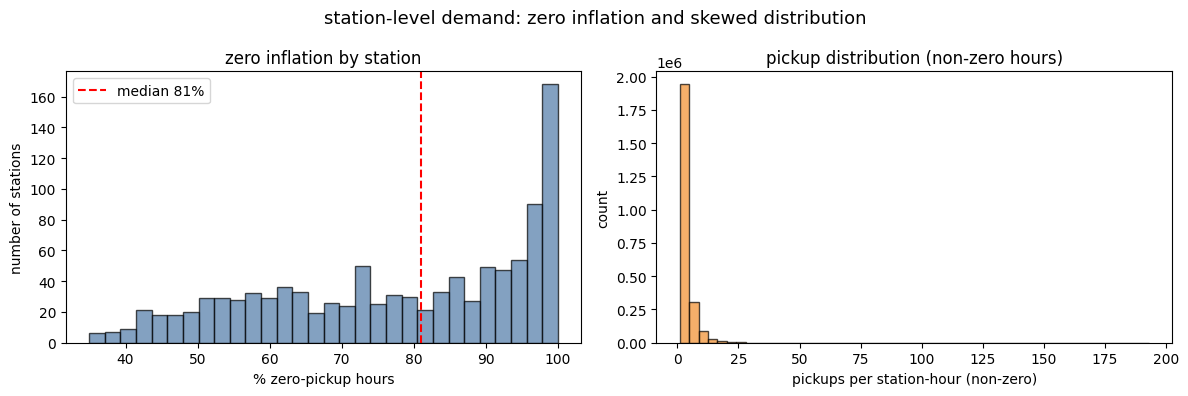

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(zeros_per_station * 100, bins=30, edgecolor="black", alpha=0.7, color="#4e79a7")
axes[0].set_xlabel("% zero-pickup hours")
axes[0].set_ylabel("number of stations")
axes[0].set_title("zero inflation by station")
axes[0].axvline(zeros_per_station.median() * 100, color="red", linestyle="--",
               label=f"median {zeros_per_station.median():.0%}")
axes[0].legend()

pickup_vals = hourly["pickups"][hourly["pickups"] > 0]
axes[1].hist(pickup_vals, bins=50, edgecolor="black", alpha=0.7, color="#f28e2b")
axes[1].set_xlabel("pickups per station-hour (non-zero)")
axes[1].set_ylabel("count")
axes[1].set_title("pickup distribution (non-zero hours)")

plt.suptitle("station-level demand: zero inflation and skewed distribution", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_station_zeros.png", dpi=150, bbox_inches="tight")
plt.show()

## K-means clustering on station lat/lon

Group stations geographically to reduce zero inflation. Run the elbow method to pick K.

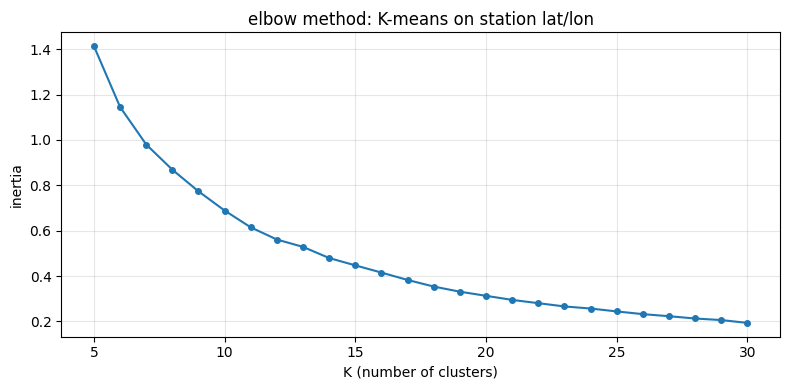

In [4]:
station_coords = stations[["station_id", "lat", "lon", "capacity"]].dropna().copy()
X = station_coords[["lat", "lon"]].values

K_range = range(5, 31)
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o", markersize=4)
plt.xlabel("K (number of clusters)")
plt.ylabel("inertia")
plt.title("elbow method: K-means on station lat/lon")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
OPTIMAL_K = 8  # adjusted after looking elbow plot 

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
station_coords["cluster_id"] = kmeans.fit_predict(X)

print(f"Assigned {len(station_coords)} stations to {OPTIMAL_K} clusters")
print(f"\nStations per cluster:")
print(station_coords["cluster_id"].value_counts().sort_index())

Assigned 1031 stations to 8 clusters

Stations per cluster:
cluster_id
0    332
1     69
2    101
3     86
4     44
5     65
6    130
7    204
Name: count, dtype: int64


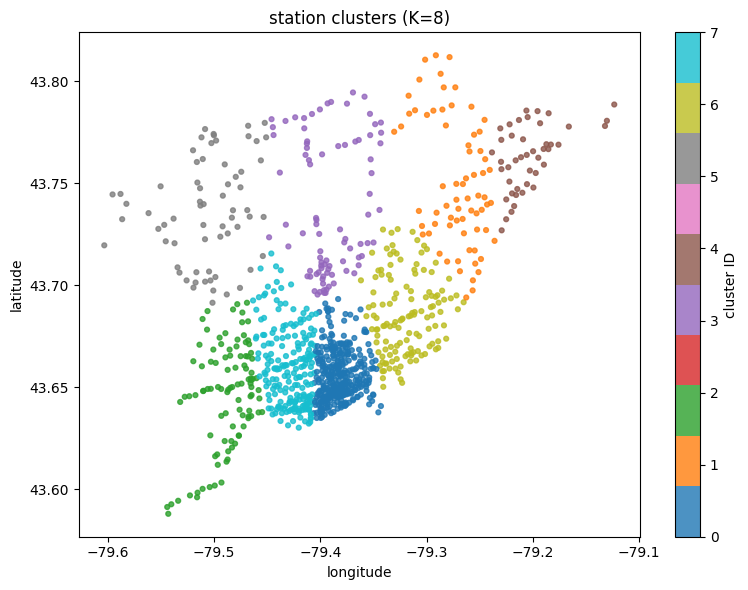

In [9]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(station_coords["lon"], station_coords["lat"],
                      c=station_coords["cluster_id"], cmap="tab10", s=12, alpha=0.8)
plt.colorbar(scatter, label="cluster ID")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title(f"station clusters (K={OPTIMAL_K})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()

## zero inflation after clustering

In [10]:
valid_stations = set(hourly["station_id"].unique()) & set(station_coords["station_id"].unique())
hourly_clust = hourly[hourly["station_id"].isin(valid_stations)].copy()
hourly_clust = hourly_clust.merge(station_coords[["station_id", "cluster_id"]], on="station_id")

cluster_hourly = hourly_clust.groupby(["cluster_id", "hour"])["pickups"].sum().reset_index()
cluster_zero_pct = (cluster_hourly["pickups"] == 0).mean()

print(f"Station-level zeros:  {zero_pct:.1%}")
print(f"Cluster-level zeros:  {cluster_zero_pct:.1%}")
print(f"\nCluster-level pickup stats:")
print(cluster_hourly["pickups"].describe())

Station-level zeros:  77.7%
Cluster-level zeros:  37.3%

Cluster-level pickup stats:
count    81408.000000
mean        85.466686
std        264.561137
min          0.000000
25%          0.000000
50%          3.000000
75%         35.000000
max       3815.000000
Name: pickups, dtype: float64


## checking cluster level zero inflation

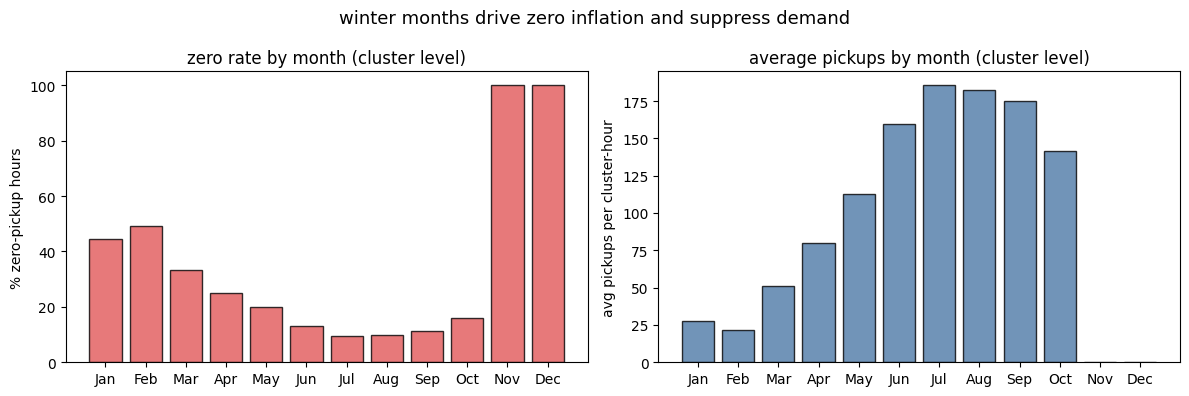

In [12]:
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

cluster_hourly["month"] = cluster_hourly["hour"].dt.month
monthly = cluster_hourly.groupby("month").agg(
    zero_rate=("pickups", lambda x: (x == 0).mean()),
    avg_pickups=("pickups", "mean")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(monthly["month"], monthly["zero_rate"] * 100,
           color="#e15759", edgecolor="black", alpha=0.8)
axes[0].set_xticks(monthly["month"])
axes[0].set_xticklabels([MONTH_LABELS[m-1] for m in monthly["month"]])
axes[0].set_ylabel("% zero-pickup hours")
axes[0].set_title("zero rate by month (cluster level)")

axes[1].bar(monthly["month"], monthly["avg_pickups"],
           color="#4e79a7", edgecolor="black", alpha=0.8)
axes[1].set_xticks(monthly["month"])
axes[1].set_xticklabels([MONTH_LABELS[m-1] for m in monthly["month"]])
axes[1].set_ylabel("avg pickups per cluster-hour")
axes[1].set_title("average pickups by month (cluster level)")

plt.suptitle("winter months drive zero inflation and suppress demand", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()

checking popular pickup timings for zero inflation check

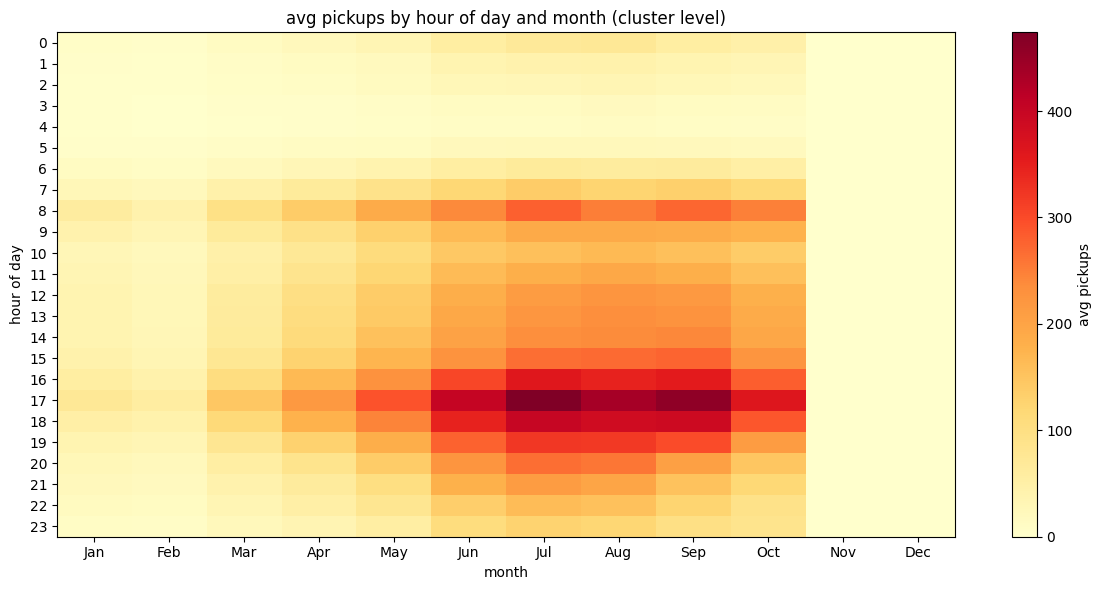

In [13]:
cluster_hourly["hour_of_day"] = cluster_hourly["hour"].dt.hour
pivot = cluster_hourly.pivot_table(
    values="pickups", index="hour_of_day", columns="month", aggfunc="mean"
)
pivot.columns = [MONTH_LABELS[m-1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(24))
ax.set_yticklabels(range(24))
ax.set_xlabel("month")
ax.set_ylabel("hour of day")
ax.set_title("avg pickups by hour of day and month (cluster level)")
plt.colorbar(im, ax=ax, label="avg pickups")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## saving cluster assignments

In [14]:
cluster_capacity = station_coords.groupby("cluster_id")["capacity"].sum().rename("cluster_capacity")
station_clusters = station_coords[["station_id", "cluster_id"]].merge(cluster_capacity, on="cluster_id")

station_clusters.to_csv(PROCESSED_DIR / "station_clusters.csv", index=False)
print(f"Saved station_clusters.csv: {len(station_clusters)} rows")
print(station_clusters.head())

Saved station_clusters.csv: 1031 rows
   station_id  cluster_id  cluster_capacity
0        7000           0              7163
1        7001           0              7163
2        7002           0              7163
3        7003           0              7163
4        7005           0              7163
